In [18]:
import json
import nbformat
import plotly.io as pio
import pandas as pd
import numpy as np
with open("clientes_genetico.json", "r", encoding="utf-8") as f:
    genetico = json.load(f)
with open("clientes_mc.json", "r", encoding="utf-8") as f:
    mc = json.load(f)

import plotly.graph_objects as go



In [19]:
n = 100
rng = np.random.default_rng(seed=42)
resultados = {}
#################
# mínimos (tem que somar <= 1)
minimos = np.array([0.2, 0.2, 0.2])  # carb, prot, lip
restante = 1 - minimos.sum()

# gera aleatório pro restante
valores = rng.dirichlet([1,1,1], size=n) * restante

# soma com mínimos
valores_final = valores + minimos
valores_final = np.round(valores_final, 2)
df = pd.DataFrame(valores_final, columns=["carboidratos", "proteinas", "lipideos"])
df["ID"] = range(1, n+1)
clientes = df[["ID", "carboidratos", "proteinas", "lipideos"]]


In [20]:
import numpy as np

erros_abs_ga = []
erros_abs_mc = []

erros_sq_ga = []
erros_sq_mc = []

for cid in genetico.keys():
    kcal_ga = np.array(genetico[cid]["kcal"])
    kcal_mc = np.array(mc[cid]["kcal"])
    alvo = np.array([
        clientes.loc[int(cid)-1, "carboidratos"],
        clientes.loc[int(cid)-1, "proteinas"],
        clientes.loc[int(cid)-1, "lipideos"]
    ])
    
    # erro relativo por solução
    if len(kcal_ga)>0:
        erro_ga = np.abs(kcal_ga - alvo) / alvo
    if len(kcal_mc)>0:
        erro_mc = np.abs(kcal_mc - alvo) / alvo
    # erro total por solução
    # MAE
    erros_abs_ga.extend(np.abs(erro_ga).flatten())
    erros_abs_mc.extend(np.abs(erro_mc).flatten())
    
    # MSE
    erros_sq_ga.extend((erro_ga**2).flatten())
    erros_sq_mc.extend((erro_mc**2).flatten())

In [21]:
mae_ga = np.mean(erros_abs_ga)
mae_mc = np.mean(erros_abs_mc)

mse_ga = np.mean(erros_sq_ga)
mse_mc = np.mean(erros_sq_mc)

print("MAE GA:", mae_ga)
print("MAE MC:", mae_mc)

print("MSE GA:", mse_ga)
print("MSE MC:", mse_mc)

MAE GA: 0.011291974906116971
MAE MC: 0.13104334701609638
MSE GA: 0.0003761184863843587
MSE MC: 0.02436216574819145


In [22]:
# coloque seus tempos reais aqui
tempo_ga = 1
tempo_mc = 0.0027

# =========================
# MONTAGEM DO RADAR
# =========================

labels = ['MAE', 'MSE', 'Tempo']

ga_values = [mae_ga, mse_ga, tempo_ga]
mc_values = [mae_mc, mse_mc, tempo_mc]

# fechar o gráfico
ga_values += [ga_values[0]]
mc_values += [mc_values[0]]
labels += [labels[0]]

fig = go.Figure()

# Algoritmo Genético (azul)
fig.add_trace(go.Scatterpolar(
    r=ga_values,
    theta=labels,
    fill='toself',
    name='Algoritmo Genético',
    line=dict(color='#1f77b4', width=3),
    fillcolor='rgba(31, 119, 180, 0.4)'
))

# Monte Carlo (laranja)
fig.add_trace(go.Scatterpolar(
    r=mc_values,
    theta=labels,
    fill='toself',
    name='Monte Carlo',
    line=dict(color='#ff7f0e', width=3),
    fillcolor='rgba(255, 127, 14, 0.4)'
))

fig.update_layout(
    title={
        'text': "Comparação de Desempenho dos Métodos",
        'x':0.5
    },
    polar=dict(
        bgcolor='#f5f7fa',
        radialaxis=dict(
            visible=True,
            range=[0,1],
            gridcolor='lightgray'
        )
    ),
    showlegend=True,
    paper_bgcolor='white'
)

# salvar
fig.write_html("radar_bonito.html")

# opcional: abrir automaticamente
import webbrowser
webbrowser.open("radar_bonito.html")

True

In [23]:
import plotly.graph_objects as go

labels = ['MAE', 'MSE', 'Tempo', 'Taxa']

# valores normalizados (usa a função nova)
ga_values = [mae_ga_n, mse_ga_n, tempo_ga_n, taxa_ga_n]
mc_values = [mae_mc_n, mse_mc_n, tempo_mc_n, taxa_mc_n]

# fechar radar
ga_values += [ga_values[0]]
mc_values += [mc_values[0]]
labels += [labels[0]]

fig = go.Figure()

# GA - azul elegante
fig.add_trace(go.Scatterpolar(
    r=ga_values,
    theta=labels,
    fill='toself',
    name='Algoritmo Genético',
    line=dict(color='#1f77b4', width=3),
    fillcolor='rgba(31, 119, 180, 0.4)'
))

# MC - laranja suave
fig.add_trace(go.Scatterpolar(
    r=mc_values,
    theta=labels,
    fill='toself',
    name='Monte Carlo',
    line=dict(color='#ff7f0e', width=3),
    fillcolor='rgba(255, 127, 14, 0.4)'
))

fig.update_layout(
    title={
        'text': "Comparação de Desempenho dos Métodos",
        'x':0.5,
        'xanchor': 'center',
        'font': dict(size=20)
    },
    polar=dict(
        bgcolor='#f5f7fa',
        radialaxis=dict(
            visible=True,
            range=[0,1],
            gridcolor='lightgray'
        )
    ),
    legend=dict(
        x=0.8,
        y=1.1,
        bgcolor='rgba(255,255,255,0.7)'
    ),
    paper_bgcolor='white'
)

fig.write_html("radar_bonito.html")

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def plot_metric(ga_mean, mc_mean, std_ga, std_mc, title):
    plt.plot(ga_mean, label="GA")
    plt.fill_between(range(len(ga_mean)),
                     ga_mean - std_ga,
                     ga_mean + std_ga,
                     alpha=0.2)

    plt.plot(mc_mean, label="MC")
    plt.fill_between(range(len(mc_mean)),
                     mc_mean - std_mc,
                     mc_mean + std_mc,
                     alpha=0.2)

    plt.legend()
    plt.title(title)
    plt.show()

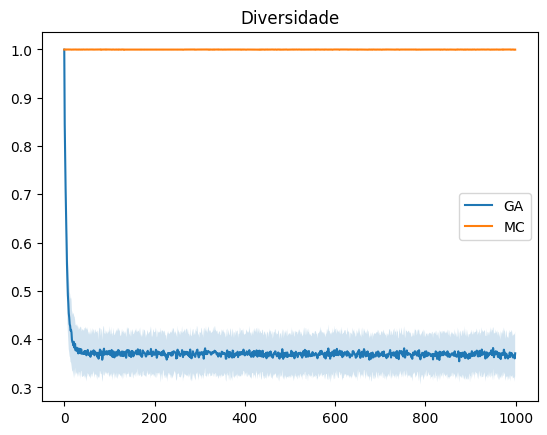

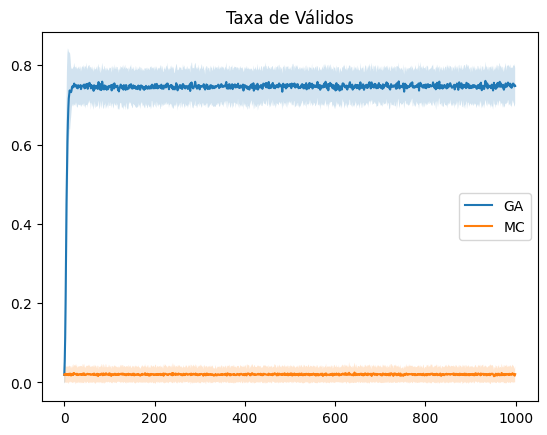

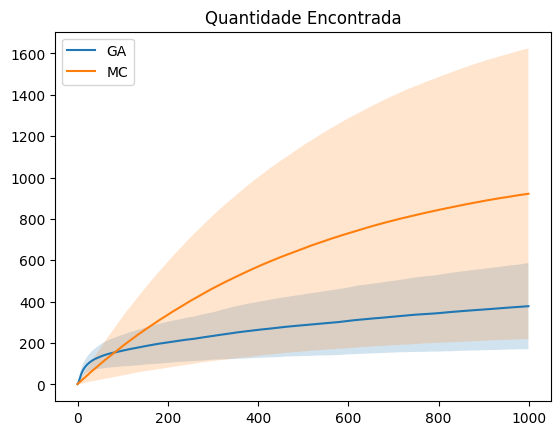

In [ ]:
plot_metric(div_ga_mean, div_mc_mean, div_std_ga, div_std_mc, "Diversidade")
plot_metric(val_ga_mean, val_mc_mean, val_std_ga, val_std_mc, "Taxa de Válidos")
plot_metric(enc_ga_mean, enc_mc_mean, enc_std_ga, enc_std_mc, "Quantidade Encontrada")

In [ ]:
td_cliente =[v["ids"] for v in mc.values()]
quantos=0
for i, ids_mc in enumerate(td_cliente):
    print(f"Cliente {i+1}: {len(ids_mc)} soluções")

    ids_mc_sorted = np.sort(ids_mc, axis=1)
    ids_unicos = np.unique(ids_mc_sorted, axis=0)

    print("Total:", len(ids_mc))
    print("Únicos:", len(ids_unicos))
    quantos += len(ids_mc)

Cliente 1: 1299 soluções
Total: 1299
Únicos: 1299
Cliente 2: 284 soluções
Total: 284
Únicos: 284
Cliente 3: 1040 soluções
Total: 1040
Únicos: 1040
Cliente 4: 293 soluções
Total: 293
Únicos: 293
Cliente 5: 301 soluções
Total: 301
Únicos: 301
Cliente 6: 923 soluções
Total: 923
Únicos: 923
Cliente 7: 617 soluções
Total: 617
Únicos: 617
Cliente 8: 2515 soluções
Total: 2515
Únicos: 2515
Cliente 9: 778 soluções
Total: 778
Únicos: 778
Cliente 10: 936 soluções
Total: 936
Únicos: 936
Cliente 11: 1664 soluções
Total: 1664
Únicos: 1664
Cliente 12: 2230 soluções
Total: 2230
Únicos: 2230
Cliente 13: 1198 soluções
Total: 1198
Únicos: 1198
Cliente 14: 2409 soluções
Total: 2409
Únicos: 2409
Cliente 15: 275 soluções
Total: 275
Únicos: 275
Cliente 16: 676 soluções
Total: 676
Únicos: 676
Cliente 17: 922 soluções
Total: 922
Únicos: 922
Cliente 18: 249 soluções
Total: 249
Únicos: 249
Cliente 19: 146 soluções
Total: 146
Únicos: 146
Cliente 20: 766 soluções
Total: 766
Únicos: 766
Cliente 21: 1741 soluções
To